<a href="https://colab.research.google.com/github/AmanuelDaget/GBPUSD-Foreign-Exchange-Price-Pridiction-Using-LSTM-GRU-BiLSTM/blob/main/GBPUSD_Price_pridiction_Using_LSTM_GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **GBPUSD Price pridiction Using LSTM GRU**

**Environment Setup & Installations**

In [1]:
pip install yfinance seaborn plotly

**Import Libraries**

In [32]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, SimpleRNN, LSTM, GRU,
    Bidirectional, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

**CONFIGURATION**

In [33]:
DATA_PATH     = 'data/gbpusd_hourly_newyorkTimezone.csv'
MODELS_DIR    = 'models'
PLOTS_DIR     = 'plots'

LOOKBACK      = 24
TRAIN_RATIO   = 0.70
VAL_RATIO     = 0.15
BATCH_SIZE    = 64
EPOCHS        = 50
PATIENCE      = 15
UNITS         = 64
DROPOUT       = 0.20
LEARNING_RATE = 0.001

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,  exist_ok=True)

COLORS = {
    'RNN':    '#E24B4A',
    'LSTM':   '#378ADD',
    'GRU':    '#1D9E75',
    'BiLSTM': '#BA7517',
}

print('Configuration loaded.')

Configuration loaded.


**Load the data**

In [36]:
def load_csv_robust(path):
    raw = pd.read_csv(path, header=None, dtype=str)
    data_start_row = None
    for i, val in enumerate(raw.iloc[:, 0]):
        v = str(val).strip()
        try:
            pd.to_datetime(v)
            if v.lower() not in {'price', 'ticker', 'datetime', 'date', ''}:
                data_start_row = i
                break
        except:
            continue
    if data_start_row is None:
        raise ValueError('No datetime rows found.')
    ohlc_keywords = {'open', 'high', 'low', 'close'}
    col_names = None
    for i in range(data_start_row - 1, -1, -1):
        row_vals = [str(v).strip().lower() for v in raw.iloc[i].tolist()]
        if ohlc_keywords.issubset(set(row_vals)):
            col_names = [str(v).strip() for v in raw.iloc[i].tolist()]
            break
    if col_names is None:
        col_names = ['Datetime', 'Open', 'High', 'Low', 'Close']
    df_data = raw.iloc[data_start_row:].copy().reset_index(drop=True)
    df_data.columns = range(df_data.shape[1])
    df_data = df_data.set_index(0)
    df_data.index = pd.to_datetime(df_data.index, utc=True, errors='coerce')
    df_data.index.name = 'Datetime'
    df_data = df_data[df_data.index.notna()]
    df_data.columns = col_names[1:][:df_data.shape[1]]
    df_data = df_data.apply(pd.to_numeric, errors='coerce')
    return df_data

df_raw = load_csv_robust(DATA_PATH)
print(f'Raw shape: {df_raw.shape}  |  {df_raw.index[0]} → {df_raw.index[-1]}')


Raw shape: (11825, 4)  |  2024-06-16 23:00:00+00:00 → 2026-05-15 21:00:00+00:00


# **DATA PREPROCESSING**

In [37]:
df = df_raw.copy()

**Keep only OHLC columns**

In [39]:
required = ["Open", "High", "Low", "Close"]
missing_cols = [c for c in required if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. "
                     f"Available: {list(df.columns)}")
df = df[required].copy()
print(f"  [2.2] Kept columns : {required}")

  [2.2] Kept columns : ['Open', 'High', 'Low', 'Close']


**Convert index to New York timezone**

In [40]:
# The loader already parsed the index as UTC-aware (utc=True).
# We just convert to New York local time — pandas handles EDT/EST DST.
df.index = df.index.tz_convert("America/New_York")
df.sort_index(inplace=True)
df.index.name = "Datetime"
print(f"  [2.3] Timezone     : {df.index.tz}")
print(f"        Date range   : {df.index[0]}  →  {df.index[-1]}")
print(f"        Total rows   : {len(df):,}")

  [2.3] Timezone     : America/New_York
        Date range   : 2024-06-16 19:00:00-04:00  →  2026-05-15 17:00:00-04:00
        Total rows   : 11,825


**Remove duplicate timestamps**

In [41]:
n_before = len(df)
df = df[~df.index.duplicated(keep="first")]
n_dupes = n_before - len(df)
print(f"  [2.4] Duplicate timestamps removed : {n_dupes}")

  [2.4] Duplicate timestamps removed : 0


**Detect & report missing values BEFORE filling**

In [42]:
print(f"\n  [2.5] Missing value report (before treatment):")
for col in df.columns:
    n_nan = df[col].isna().sum()
    pct   = n_nan / len(df) * 100
    print(f"        {col:<8} → {n_nan:>4} NaN  ({pct:.2f}%)")


  [2.5] Missing value report (before treatment):
        Open     →    0 NaN  (0.00%)
        High     →    0 NaN  (0.00%)
        Low      →    0 NaN  (0.00%)
        Close    →    0 NaN  (0.00%)


Detect & fill missing hourly gaps in the time index

In [43]:
full_idx   = pd.date_range(start=df.index.min(),
                            end=df.index.max(),
                            freq="1h",
                            tz=df.index.tz)
missing_ts = full_idx.difference(df.index)
# Classify missing timestamps as weekend (expected) vs weekday (data gap)
weekend_missing  = [t for t in missing_ts if t.weekday() >= 5]
weekday_missing  = [t for t in missing_ts if t.weekday() <  5]

print(f"\n  [2.7] Missing hourly timestamps:")
print(f"        Weekend gaps  (expected) : {len(weekend_missing):>5}")
print(f"        Weekday gaps (data issue): {len(weekday_missing):>5}")

if weekday_missing:
    # Reindex to full hourly frequency, fill new rows by forward-fill
    df = df.reindex(full_idx)
    df.ffill(inplace=True)
    df.bfill(inplace=True)
    # Drop weekend rows (no trading — do NOT feed zero-movement hours to model)
    df = df[df.index.weekday < 5]
    print(f"        Weekday gaps filled via ffill. Weekend rows excluded.")
else:
    # No weekday gaps — just drop weekend rows
    df = df[df.index.weekday < 5]
    print(f"        No weekday gaps found. Weekend rows excluded.")

print(f"        Rows after gap handling  : {len(df):,}")


  [2.7] Missing hourly timestamps:
        Weekend gaps  (expected) :  4270
        Weekday gaps (data issue):   656
        Weekday gaps filled via ffill. Weekend rows excluded.
        Rows after gap handling  : 11,994


**Outlier detection & capping (IQR method per column)**

In [44]:
print(f"\n  [2.8] Outlier capping (IQR × 3.0):")
for col in df.columns:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 3.0 * IQR
    hi  = Q3 + 3.0 * IQR
    n_outliers = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lower=lo, upper=hi)
    print(f"        {col:<8} → {n_outliers:>3} outliers capped  "
          f"[{lo:.5f}, {hi:.5f}]")


  [2.8] Outlier capping (IQR × 3.0):
        Open     →   0 outliers capped  [1.12049, 1.51564]
        High     →   0 outliers capped  [1.12148, 1.51621]
        Low      →   0 outliers capped  [1.11904, 1.51559]
        Close    →   0 outliers capped  [1.12043, 1.51569]


Sanity checks

In [45]:
invalid_hl    = (df["High"] < df["Low"]).sum()
invalid_close = ((df["Close"] < df["Low"]) | (df["Close"] > df["High"])).sum()
print(f"\n  [2.9] Sanity checks:")
print(f"        High < Low  violations : {invalid_hl}")
print(f"        Close out of HL range  : {invalid_close}")

# Fix High < Low by swapping (rare but possible in raw data)
if invalid_hl > 0:
    mask = df["High"] < df["Low"]
    df.loc[mask, ["High", "Low"]] = df.loc[mask, ["Low", "High"]].values
    print(f"        Swapped {invalid_hl} High/Low pairs.")


  [2.9] Sanity checks:
        High < Low  violations : 0
        Close out of HL range  : 0


**Stationarity check (Augmented Dickey-Fuller test on Close)**

In [46]:
from statsmodels.tsa.stattools import adfuller

print(f"\n  [2.10] Stationarity — ADF test on Close price:")
adf_result = adfuller(df["Close"].dropna(), autolag="AIC")
print(f"         ADF Statistic : {adf_result[0]:.4f}")
print(f"         p-value       : {adf_result[1]:.4f}")
print(f"         Critical vals : {adf_result[4]}")
if adf_result[1] < 0.05:
    print("         Conclusion    : Series is STATIONARY (p < 0.05) ✓")
else:
    print("         Conclusion    : Series is NON-STATIONARY (p ≥ 0.05)")
    print("         Note          : Models will learn from normalised returns — OK.")


  [2.10] Stationarity — ADF test on Close price:
         ADF Statistic : -1.9451
         p-value       : 0.3111
         Critical vals : {'1%': np.float64(-3.430895421974555), '5%': np.float64(-2.861781048477914), '10%': np.float64(-2.5668983050566623)}
         Conclusion    : Series is NON-STATIONARY (p ≥ 0.05)
         Note          : Models will learn from normalised returns — OK.


**Final preprocessing summary**

In [47]:
print(f"\n  {'─'*50}")
print(f"  Preprocessing complete.")
print(f"  Final dataset shape : {df.shape}")
print(f"  Date range          : {df.index[0]}  →  {df.index[-1]}")
print(f"  Remaining NaN       : {df.isna().sum().sum()}")
print(f"  {'─'*50}")
print(f"\n  Descriptive statistics:")
print(df.describe().round(6).to_string())


  ──────────────────────────────────────────────────
  Preprocessing complete.
  Final dataset shape : (11994, 4)
  Date range          : 2024-06-17 00:00:00-04:00  →  2026-05-15 17:00:00-04:00
  Remaining NaN       : 0
  ──────────────────────────────────────────────────

  Descriptive statistics:
               Open          High           Low         Close
count  11994.000000  11994.000000  11994.000000  11994.000000
mean       1.316081      1.316798      1.315378      1.316089
std        0.037301      0.037288      0.037305      0.037297
min        1.210874      1.213209      1.210126      1.210771
25%        1.289840      1.290647      1.288992      1.289827
50%        1.327387      1.328295      1.326658      1.327378
75%        1.346289      1.347037      1.345641      1.346294
max        1.384792      1.386866      1.383700      1.385003


**EXPLORATORY DATA ANALYSIS PLOT**


[STEP 3]  Plotting raw data overview ...


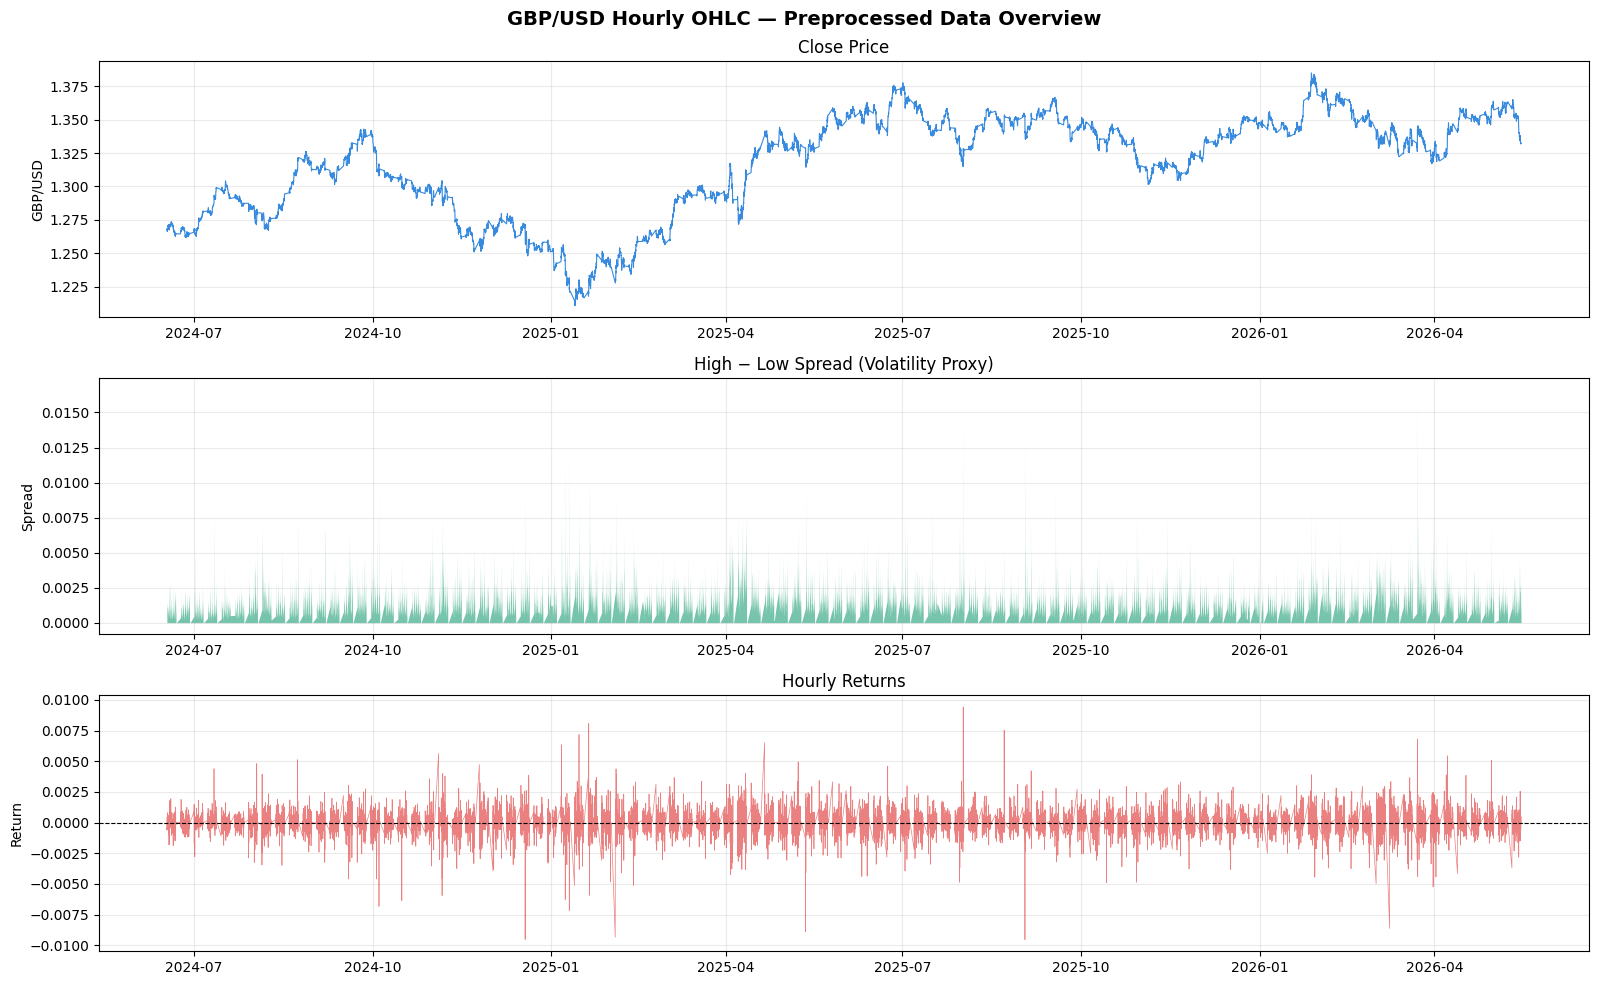

  Saved  →  plots/00_data_overview.png


In [60]:
import os

print("\n[STEP 3]  Plotting raw data overview ...")

os.makedirs(PLOTS_DIR, exist_ok=True)

fig, axes = plt.subplots(3, 1, figsize=(16, 10))
fig.suptitle("GBP/USD Hourly OHLC — Preprocessed Data Overview",
             fontsize=14, fontweight="bold")

# Close price
axes[0].plot(df.index, df["Close"], color="#378ADD", linewidth=0.8)
axes[0].set_title("Close Price")
axes[0].set_ylabel("GBP/USD")
axes[0].grid(True, alpha=0.25)

# High - Low spread
axes[1].fill_between(df.index,
                     df["High"] - df["Low"],
                     color="#1D9E75", alpha=0.6, linewidth=0)
axes[1].set_title("High − Low Spread (Volatility Proxy)")
axes[1].set_ylabel("Spread")
axes[1].grid(True, alpha=0.25)

# Hourly returns
ret = df["Close"].pct_change().dropna()
axes[2].plot(df.index[1:], ret, color="#E24B4A", linewidth=0.5, alpha=0.7)
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_title("Hourly Returns")
axes[2].set_ylabel("Return")
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "00_data_overview.png")
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()
print(f"  Saved  →  {path}")

**Feature engineering**

In [61]:
fe = df.copy()
fe['returns']    = fe['Close'].pct_change()
fe['hl_spread']  = fe['High']  - fe['Low']
fe['oc_spread']  = fe['Close'] - fe['Open']
fe['sma_10']     = fe['Close'].rolling(10).mean()
fe['sma_24']     = fe['Close'].rolling(24).mean()
fe['ema_12']     = fe['Close'].ewm(span=12, adjust=False).mean()
fe['momentum']   = fe['Close'] - fe['Close'].shift(4)
fe['volatility'] = fe['returns'].rolling(12).std()
fe.dropna(inplace=True)

FEATURES = [
    'Open', 'High', 'Low', 'Close',
    'returns', 'hl_spread', 'oc_spread',
    'sma_10', 'sma_24', 'ema_12', 'momentum', 'volatility',
]
CLOSE_IDX = FEATURES.index('Close')


print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'Scaled shape: {scaled.shape}')

Features (12): ['Open', 'High', 'Low', 'Close', 'returns', 'hl_spread', 'oc_spread', 'sma_10', 'sma_24', 'ema_12', 'momentum', 'volatility']
Scaled shape: (11971, 12)


**Normalize features**

In [62]:
print("\n[STEP 5]  Normalising features with MinMaxScaler [0, 1] ...")

scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(fe[FEATURES].values)

print(f"  Scaled array shape : {scaled.shape}")
print(f"  Min after scaling  : {scaled.min():.4f}  (should be 0.0)")
print(f"  Max after scaling  : {scaled.max():.4f}  (should be 1.0)")


[STEP 5]  Normalising features with MinMaxScaler [0, 1] ...
  Scaled array shape : (11971, 12)
  Min after scaling  : 0.0000  (should be 0.0)
  Max after scaling  : 1.0000  (should be 1.0)


**SEQUENCE CREATION  (sliding window — lookback = 24 hours)**

In [63]:
def create_sequences(data: np.ndarray, lookback: int, target_idx: int):
    """
    Build (X, y) pairs with a sliding window.

    For each position i from lookback to end:
      X[i] = data[i-lookback : i]     shape → (lookback, n_features)
      y[i] = data[i, target_idx]      shape → scalar  (next Close, scaled)

    The window slides one step at a time, so every hour produces one sample.
    """
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback : i])    # input: past 24 hours
        y.append(data[i, target_idx])       # target: next hour Close
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


print(f"\n[STEP 6]  Creating sequences (lookback = {LOOKBACK} hours) ...")

X, y = create_sequences(scaled, LOOKBACK, CLOSE_IDX)
print(f"  X shape : {X.shape}   →  (samples, timesteps, features)")
print(f"  y shape : {y.shape}   →  (samples,)")


[STEP 6]  Creating sequences (lookback = 24 hours) ...
  X shape : (11947, 24, 12)   →  (samples, timesteps, features)
  y shape : (11947,)   →  (samples,)


**Train / Validation / Test split**

In [64]:
print("\n[STEP 7]  Splitting data (no shuffle — time-series) ...")

n       = len(X)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)
n_test  = n - n_train - n_val

X_train, y_train = X[:n_train],               y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val],  y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],         y[n_train+n_val:]

print(f"  Total sequences : {n:,}")
print(f"  Train   70 %    : {X_train.shape[0]:,} samples")
print(f"  Val     15 %    : {X_val.shape[0]:,} samples")
print(f"  Test    15 %    : {X_test.shape[0]:,} samples")

INPUT_SHAPE = (LOOKBACK, len(FEATURES))   # (24, 12)


[STEP 7]  Splitting data (no shuffle — time-series) ...
  Total sequences : 11,947
  Train   70 %    : 8,362 samples
  Val     15 %    : 1,792 samples
  Test    15 %    : 1,793 samples


# **MODEL**

**SHARED UTILITIES**

In [65]:
def inverse_close(scaled_vals):
    dummy = np.zeros((len(scaled_vals), len(FEATURES)))
    dummy[:, CLOSE_IDX] = scaled_vals
    return scaler.inverse_transform(dummy)[:, CLOSE_IDX]


def compute_metrics(actual, preds):
    """RMSE, NRMSE(%), MAE, MAPE(%), DA(%)"""
    rmse  = float(np.sqrt(mean_squared_error(actual, preds)))
    nrmse = float(rmse / (actual.max() - actual.min()) * 100)
    mae   = float(mean_absolute_error(actual, preds))
    mape  = float(np.mean(np.abs((actual - preds) / (actual + 1e-9))) * 100)
    da    = float(np.mean(np.sign(np.diff(actual)) == np.sign(np.diff(preds))) * 100)
    return {'RMSE': rmse, 'NRMSE (%)': nrmse, 'MAE': mae, 'MAPE (%)': mape, 'DA (%)': da}


def print_metrics(metrics, split_name='Validation'):
    print(f'\n  ── {split_name} Metrics ──────────────────────')
    for k, v in metrics.items():
        print(f'    {k:<14}: {v:.6f}')
    print()


def evaluate_split(model, X_split, y_split, split_name='Validation'):
    preds_sc = model.predict(X_split, verbose=0).flatten()
    preds    = inverse_close(preds_sc)
    actual   = inverse_close(y_split)
    metrics  = compute_metrics(actual, preds)
    print_metrics(metrics, split_name)
    return preds, actual, metrics


def train_model(model, X_tr, y_tr, X_v, y_v):
    name      = model.name
    ckpt_path = os.path.join(MODELS_DIR, f'{name}_best.weights.h5')
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=PATIENCE,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=7, min_lr=1e-6, verbose=0),
        ModelCheckpoint(ckpt_path, monitor='val_loss',
                        save_best_only=True, save_weights_only=True, verbose=0),
    ]
    print(f'\n  Training [{name}]  —  {model.count_params():,} parameters')
    t0 = time.time()
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        callbacks=callbacks, verbose=1,
    )
    elapsed = time.time() - t0
    best_ep = int(np.argmin(history.history['val_loss'])) + 1
    print(f'  Best epoch: {best_ep}  |  val_loss: {min(history.history["val_loss"]):.6f}  |  Time: {elapsed:.1f}s')
    return history, elapsed


COLORS = {
    "RNN":    "#E24B4A",
    "LSTM":   "#378ADD",
    "GRU":    "#1D9E75",
    "BiLSTM": "#BA7517",
}

def plot_loss_curve(history, model_name):
    h   = history.history
    eps = range(1, len(h['loss']) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(eps, h['loss'],     label='Train Loss', color=COLORS[model_name], lw=2)
    plt.plot(eps, h['val_loss'], label='Val Loss',   color=COLORS[model_name], lw=2, ls='--', alpha=0.7)
    plt.title(f'[{model_name}] Training vs Validation Loss', fontsize=12, fontweight='bold')
    plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
    plt.legend(); plt.grid(alpha=0.25); plt.tight_layout()
    path = os.path.join(PLOTS_DIR, f'{model_name}_loss_curve.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved → {path}')


def plot_val_predictions(preds_val, actual_val, model_name):
    plt.figure(figsize=(14, 4))
    plt.plot(actual_val, color='black',          lw=1.4, label='Actual',           alpha=0.9)
    plt.plot(preds_val,  color=COLORS[model_name], lw=1.2, label=f'{model_name} Pred', alpha=0.85)
    m = compute_metrics(actual_val, preds_val)
    subtitle = (f"RMSE={m['RMSE']:.5f}  NRMSE={m['NRMSE (%)']:.2f}%  "
                f"MAE={m['MAE']:.5f}  MAPE={m['MAPE (%)']:.2f}%  DA={m['DA (%)']:.1f}%")
    plt.title(f'[{model_name}] VALIDATION Set\n{subtitle}', fontsize=10,
              color=COLORS[model_name], fontweight='bold')
    plt.xlabel('Hours'); plt.ylabel('GBP/USD')
    plt.legend(); plt.grid(alpha=0.2); plt.tight_layout()
    path = os.path.join(PLOTS_DIR, f'{model_name}_validation.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved → {path}')


def plot_test_predictions(preds_test, actual_test, model_name):
    plt.figure(figsize=(14, 4))
    plt.plot(actual_test, color='black',           lw=1.4, label='Actual',           alpha=0.9)
    plt.plot(preds_test,  color=COLORS[model_name], lw=1.2, label=f'{model_name} Pred', alpha=0.85)
    m = compute_metrics(actual_test, preds_test)
    subtitle = (f"RMSE={m['RMSE']:.5f}  NRMSE={m['NRMSE (%)']:.2f}%  "
                f"MAE={m['MAE']:.5f}  MAPE={m['MAPE (%)']:.2f}%  DA={m['DA (%)']:.1f}%")
    plt.title(f'[{model_name}] TEST Set\n{subtitle}', fontsize=10,
              color=COLORS[model_name], fontweight='bold')
    plt.xlabel('Hours'); plt.ylabel('GBP/USD')
    plt.legend(); plt.grid(alpha=0.2); plt.tight_layout()
    path = os.path.join(PLOTS_DIR, f'{model_name}_test.png')
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved → {path}')


# Master results store
results = {}
print('Utilities ready.')

Utilities ready.


**MODEL 1 — LSTM**

In [66]:
# %% [LSTM — 1a] Define
def build_lstm(input_shape, units, dropout, lr):
    model = Sequential(name='LSTM')
    model.add(LSTM(units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout))
    model.add(LSTM(units, return_sequences=False))
    model.add(Dropout(dropout))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=Adam(lr), loss='mse', metrics=['mae'])
    return model

lstm_model = build_lstm(INPUT_SHAPE, UNITS, DROPOUT, LEARNING_RATE)
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 24, 64)         │        19,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,849 (214.25 KB)

 Trainable params: 54,849 (214.25 KB)

 Non-trainable params: 0 (0.00 B)

**LSTM Train**


  Training [LSTM]  —  54,849 parameters
Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0118 - mae: 0.0668 - val_loss: 0.0013 - val_mae: 0.0295 - learning_rate: 0.0010
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0022 - mae: 0.0360 - val_loss: 4.6308e-04 - val_mae: 0.0149 - learning_rate: 0.0010
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0018 - mae: 0.0320 - val_loss: 0.0017 - val_mae: 0.0367 - learning_rate: 0.0010
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0015 - mae: 0.0295 - val_loss: 0.0016 - val_mae: 0.0352 - learning_rate: 0.0010
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0013 - mae: 0.0270 - val_loss: 0.0031 - val_mae: 0.0522 - learning_rate: 0.0010
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0010 - mae: 0.0244 - val_loss: 0.0011 - val_mae: 0.0288 - learning_rate: 0.0010
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 9.3081e-04 - mae: 0.0231 - val_loss: 0.0

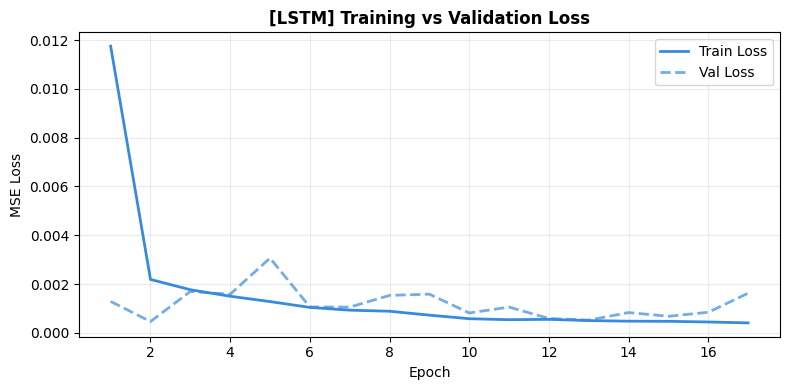

  Saved → plots/LSTM_loss_curve.png


In [68]:
os.makedirs(PLOTS_DIR, exist_ok=True)
lstm_history, lstm_time = train_model(lstm_model, X_train, y_train, X_val, y_val)
plot_loss_curve(lstm_history, 'LSTM')

**LSTM VALIDATE  ← check metrics here before running t**

  LSTM — VALIDATION METRICS  (review before testing!)

  ── LSTM Validation Metrics ──────────────────────
    RMSE          : 0.003749
    NRMSE (%)     : 4.491375
    MAE           : 0.002594
    MAPE (%)      : 0.193122
    DA (%)        : 46.286991



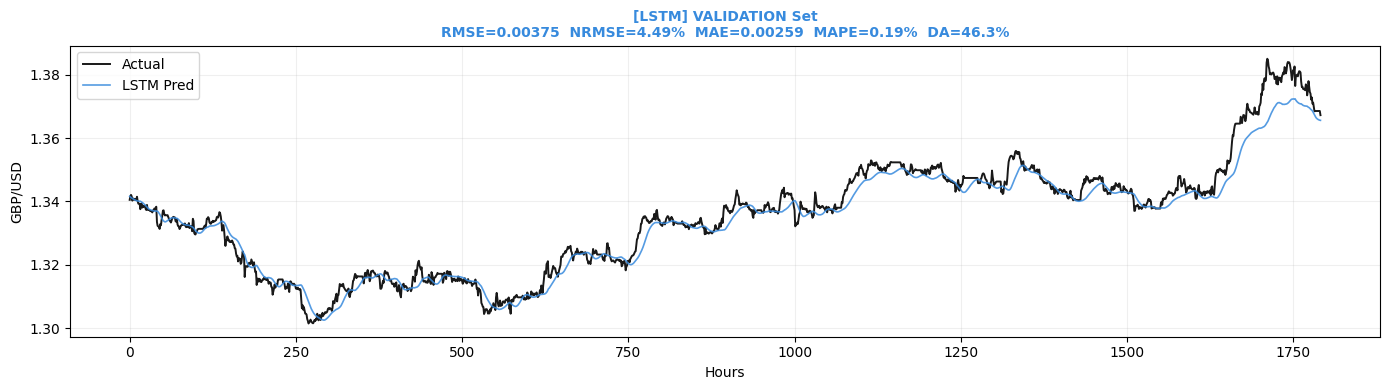

  Saved → plots/LSTM_validation.png
  ✅ If metrics look good, run the TEST cell below.


In [69]:
print('=' * 60)
print('  LSTM — VALIDATION METRICS  (review before testing!)')
print('=' * 60)
lstm_preds_val, lstm_actual_val, lstm_val_metrics = evaluate_split(
    lstm_model, X_val, y_val, split_name='LSTM Validation'
)
plot_val_predictions(lstm_preds_val, lstm_actual_val, 'LSTM')
print('  ✅ If metrics look good, run the TEST cell below.')